Cell - 1 : Imports and paths:

In [2]:
import os
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

Cell - 2 : Define project paths & verify raw dataset

In [2]:

BASE_DIR = os.getcwd() if os.path.basename(os.getcwd()) != "notebook" else os.path.abspath("..")
RAW_DIR = os.path.join(BASE_DIR, "data_raw", "Vehicle DS")

print("Base directory:")
print(BASE_DIR)

print("\nRaw dataset directory exists:")
print(os.path.exists(RAW_DIR))

print("\nFolders inside raw dataset:")
os.listdir(RAW_DIR)


Base directory:
c:\HTML\FL_IDS_Vehicle

Raw dataset directory exists:
True

Folders inside raw dataset:


['Benign', 'Botnet', 'Brute_Force', 'DDoS_or_LOIC', 'DoS', 'SQL_Injection']

Cell-3 : Locate ZIP files (Benign)

In [6]:
zip_files = []
for root, _, files in os.walk(benign_dir):
    for f in files:
        if f.endswith(".zip"):
            zip_files.append(os.path.join(root, f))

print("Number of Benign ZIP files found:", len(zip_files))
print("\nBenign ZIP file paths:")
zip_files[:4]


Number of Benign ZIP files found: 4

Benign ZIP file paths:


['c:\\HTML\\FL_IDS_Vehicle\\data_raw\\Vehicle DS\\Benign\\friday_02_03_2018_benign.zip',
 'c:\\HTML\\FL_IDS_Vehicle\\data_raw\\Vehicle DS\\Benign\\friday_16_02_2018_benign_part1.zip',
 'c:\\HTML\\FL_IDS_Vehicle\\data_raw\\Vehicle DS\\Benign\\friday_16_02_2018_benign_part2.zip',
 'c:\\HTML\\FL_IDS_Vehicle\\data_raw\\Vehicle DS\\Benign\\friday_16_02_2018_benign_part3.zip']

Cell - 4 : Inspect contents of ONE ZIP file:

In [8]:

import zipfile

zip_path = zip_files[0]

print("Inspecting ZIP file:")
print(zip_path)

with zipfile.ZipFile(zip_path, 'r') as z:
    files_inside = z.namelist()
    print("\nFiles inside the ZIP:")
    for f in files_inside:
        print(f)


Inspecting ZIP file:
c:\HTML\FL_IDS_Vehicle\data_raw\Vehicle DS\Benign\friday_02_03_2018_benign.zip

Files inside the ZIP:
friday_02_03_2018_benign.csv


Cell - 5 : Load a small sample directly from the ZIP:

In [9]:

csv_name = "friday_02_03_2018_benign.csv"

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(csv_name) as f:
        sample_df = pd.read_csv(f, nrows=5000, low_memory=False)

sample_df.head()


,flow_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,duration,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,bwd_total_payload_bytes,payload_bytes_max,payload_bytes_min,payload_bytes_mean,payload_bytes_std,payload_bytes_variance,payload_bytes_median,payload_bytes_skewness,payload_bytes_cov,payload_bytes_mode,fwd_payload_bytes_max,fwd_payload_bytes_min,fwd_payload_bytes_mean,fwd_payload_bytes_std,fwd_payload_bytes_variance,fwd_payload_bytes_median,fwd_payload_bytes_skewness,fwd_payload_bytes_cov,fwd_payload_bytes_mode,bwd_payload_bytes_max,bwd_payload_bytes_min,bwd_payload_bytes_mean,bwd_payload_bytes_std,bwd_payload_bytes_variance,bwd_payload_bytes_median,bwd_payload_bytes_skewness,bwd_payload_bytes_cov,bwd_payload_bytes_mode,total_header_bytes,max_header_bytes,min_header_bytes,mean_header_bytes,std_header_bytes,median_header_bytes,skewness_header_bytes,cov_header_bytes,mode_header_bytes,variance_header_bytes,fwd_total_header_bytes,fwd_max_header_bytes,fwd_min_header_bytes,fwd_mean_header_bytes,fwd_std_header_bytes,fwd_median_header_bytes,fwd_skewness_header_bytes,fwd_cov_header_bytes,fwd_mode_header_bytes,fwd_variance_header_bytes,bwd_total_header_bytes,bwd_max_header_bytes,bwd_min_header_bytes,bwd_mean_header_bytes,bwd_std_header_bytes,bwd_median_header_bytes,bwd_skewness_header_bytes,bwd_cov_header_bytes,bwd_mode_header_bytes,bwd_variance_header_bytes,fwd_avg_segment_size,bwd_avg_segment_size,avg_segment_size,fwd_init_win_bytes,bwd_init_win_bytes,active_min,active_max,active_mean,active_std,active_median,active_skewness,active_cov,active_mode,active_variance,idle_min,idle_max,idle_mean,idle_std,idle_median,idle_skewness,idle_cov,idle_mode,idle_variance,bytes_rate,fwd_bytes_rate,bwd_bytes_rate,packets_rate,bwd_packets_rate,fwd_packets_rate,down_up_rate,avg_fwd_bytes_per_bulk,avg_fwd_packets_per_bulk,avg_fwd_bulk_rate,avg_bwd_bytes_per_bulk,avg_bwd_packets_bulk_rate,avg_bwd_bulk_rate,fwd_bulk_state_count,fwd_bulk_total_size,fwd_bulk_per_packet,fwd_bulk_duration,bwd_bulk_state_count,bwd_bulk_total_size,bwd_bulk_per_packet,bwd_bulk_duration,fin_flag_counts,psh_flag_counts,urg_flag_counts,ece_flag_counts,syn_flag_counts,ack_flag_counts,cwr_flag_counts,rst_flag_counts,fwd_fin_flag_counts,fwd_psh_flag_counts,fwd_urg_flag_counts,fwd_ece_flag_counts,fwd_syn_flag_counts,fwd_ack_flag_counts,fwd_cwr_flag_counts,fwd_rst_flag_counts,bwd_fin_flag_counts,bwd_psh_flag_counts,bwd_urg_flag_counts,bwd_ece_flag_counts,bwd_syn_flag_counts,bwd_ack_flag_counts,bwd_cwr_flag_counts,bwd_rst_flag_counts,fin_flag_percentage_in_total,psh_flag_percentage_in_total,urg_flag_percentage_in_total,ece_flag_percentage_in_total,syn_flag_percentage_in_total,ack_flag_percentage_in_total,cwr_flag_percentage_in_total,rst_flag_percentage_in_total,fwd_fin_flag_percentage_in_total,fwd_psh_flag_percentage_in_total,fwd_urg_flag_percentage_in_total,fwd_ece_flag_percentage_in_total,fwd_syn_flag_percentage_in_total,fwd_ack_flag_percentage_in_total,fwd_cwr_flag_percentage_in_total,fwd_rst_flag_percentage_in_total,bwd_fin_flag_percentage_in_total,bwd_psh_flag_percentage_in_total,bwd_urg_flag_percentage_in_total,bwd_ece_flag_percentage_in_total,bwd_syn_flag_percentage_in_total,bwd_ack_flag_percentage_in_total,bwd_cwr_flag_percentage_in_total,bwd_rst_flag_percentage_in_total,fwd_fin_flag_percentage_in_fwd_packets,fwd_psh_flag_percentage_in_fwd_packets,fwd_urg_flag_percentage_in_fwd_packets,fwd_ece_flag_percentage_in_fwd_packets,fwd_syn_flag_percentage_in_fwd_packets,fwd_ack_flag_percentage_in_fwd_packets,fwd_cwr_flag_percentage_in_fwd_packets,fwd_rst_flag_percentage_in_fwd_packets,bwd_fin_flag_percentage_in_bwd_packets,bwd_psh_flag_percentage_in_bwd_packets,bwd_urg_flag_percentage_in_bwd_packets,bwd_ece_flag_percentage_in_bwd_packets,bwd_syn_flag_percentage_in_bwd_packets,bwd_ack_flag_percentage_in_bwd_packets,bwd_cwr_flag_percentage_in_bwd_packets,bwd_rst_flag_percentage_in_bwd_packets,packets_IAT_mean,packet_IAT_std,packet

Cell-6: Dataset shape, dimensions & quick summary:

In [10]:

print("Dataset shape (rows, columns):")
print(sample_df.shape)

print("\nNumber of rows:", sample_df.shape[0])
print("Number of columns:", sample_df.shape[1])

print("\nColumn data types (top 15):")
sample_df.dtypes.head(15)


Dataset shape (rows, columns):
(5000, 323)

Number of rows: 5000
Number of columns: 323

Column data types (top 15):


flow_id                     object
timestamp                   object
src_ip                      object
src_port                     int64
dst_ip                      object
dst_port                     int64
protocol                    object
duration                   float64
packets_count                int64
fwd_packets_count            int64
bwd_packets_count            int64
total_payload_bytes          int64
fwd_total_payload_bytes      int64
bwd_total_payload_bytes      int64
payload_bytes_max            int64
dtype: object

Cell - 7 : Identify columns to DROP (inspection only)

In [11]:
object_cols = sample_df.select_dtypes(include=["object"]).columns.tolist()

print("Number of object (non-numeric) columns:", len(object_cols))
print("\nObject columns:")
for col in object_cols:
    print(col)


Number of object (non-numeric) columns: 8

Object columns:
flow_id
timestamp
src_ip
dst_ip
protocol
delta_start
handshake_duration
label


Cell - 8 : Quick numeric overview (what kind of data we have)

In [12]:
# Cell 10: Quick statistical overview of numeric features

sample_df.describe().T.head(10)


c:\HTML\FL_IDS_Vehicle\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\HTML\FL_IDS_Vehicle\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\HTML\FL_IDS_Vehicle\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\HTML\FL_IDS_Vehicle\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\HTML\FL_IDS_Vehicle\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\HTML\FL_IDS_Vehicle\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
 

,count,mean,std,min,25%,50%,75%,max
src_port,5000.0,43493.807400,20493.043527,80.0,49545.75,50200.000000,53715.75000,6.553400e+04
dst_port,5000.0,9502.963800,18111.598777,22.0,443.00,445.000000,3389.00000,5.834600e+04
duration,5000.0,26.626096,74.825559,0.0,0.00,1.680629,5.29766,1.265864e+03
packets_count,5000.0,21.248800,110.086211,1.0,1.00,14.000000,18.00000,5.153000e+03
fwd_packets_count,5000.0,8.884400,21.887047,0.0,1.00,8.000000,9.00000,6.150000e+02
bwd_packets_count,5000.0,12.364400,93.338307,0.0,1.00,7.000000,8.00000,4.621000e+03
total_payload_bytes,5000.0,10439.333000,132532.626184,0.0,0.00,1235.000000,2771.00000,6.690221e+06
fwd_total_payload_bytes,5000.0,1088.777600,6159.051200,0.0,0.00,451.000000,1144.00000,2.093680e+05
bwd_total_payload_bytes,5000.0,9350.555400,132035.053818,0.0,0.00,706.000000,1618.00000,6.684929e+06
payload_bytes_max,5000.0,792.282800,1754.756853,0.0,0.00,706.000000,1173.00000,3.504000e+04


Cell - 9: Label distribution (Benign vs Attack):

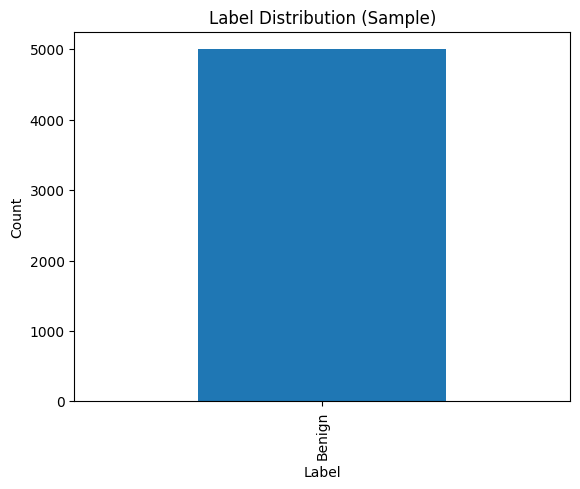

In [13]:
# Cell 11: Visualize label distribution

import matplotlib.pyplot as plt

sample_df["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution (Sample)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


Cell-10: Visualize feature distributions (histograms)

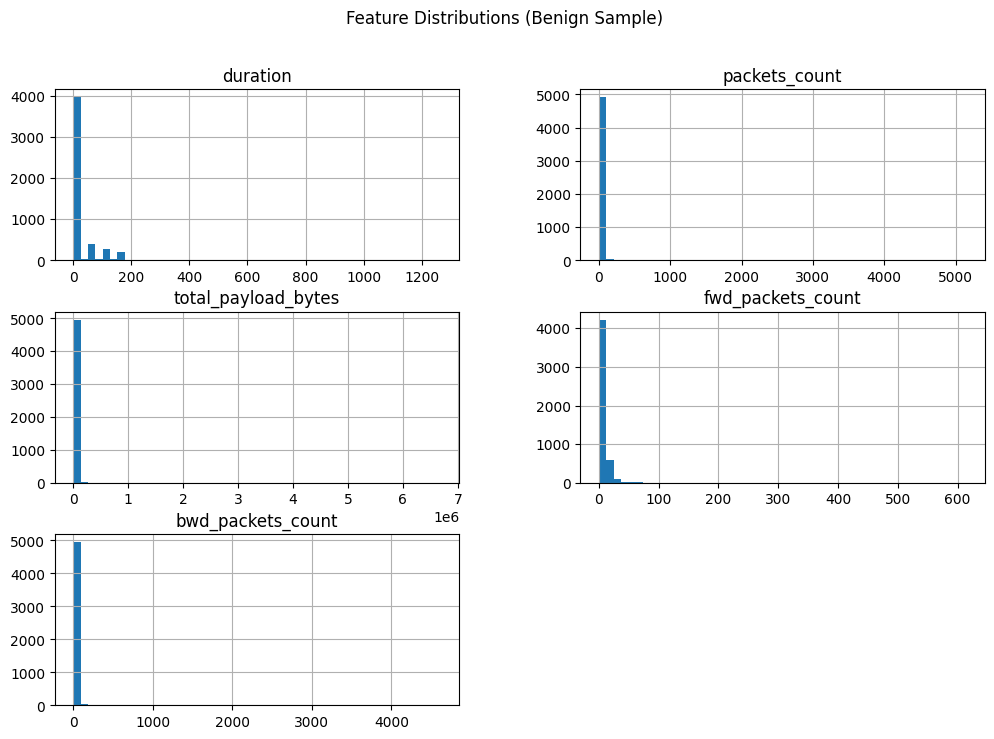

In [14]:
# Cell 12: Visualize distributions of a few important numeric features

features_to_plot = [
    "duration",
    "packets_count",
    "total_payload_bytes",
    "fwd_packets_count",
    "bwd_packets_count"
]

sample_df[features_to_plot].hist(bins=50, figsize=(12, 8))
plt.suptitle("Feature Distributions (Benign Sample)")
plt.show()


Cell-11: Inspect ONE attack CSV (DoS)

In [ ]:

dos_dir = os.path.join(RAW_DIR, "DoS")

dos_zip_files = []
for root, _, files in os.walk(dos_dir):
    for f in files:
        if f.endswith(".zip"):
            dos_zip_files.append(os.path.join(root, f))

print("Number of DoS ZIP files:", len(dos_zip_files))
dos_zip_files[:2]


Number of DoS ZIP files: 2


['c:\\HTML\\FL_IDS_Vehicle\\data_raw\\Vehicle DS\\DoS\\thursday_15_02_2018_DoS_Golden_Eye.zip',
 'c:\\HTML\\FL_IDS_Vehicle\\data_raw\\Vehicle DS\\DoS\\thursday_15_02_2018_DoS_Slowloris.zip']

Cell-12: Inspect contents of ONE DoS ZIP file

In [16]:

dos_zip_path = dos_zip_files[0]  # take the first DoS zip

print("Inspecting DoS ZIP file:")
print(dos_zip_path)

with zipfile.ZipFile(dos_zip_path, 'r') as z:
    dos_files_inside = z.namelist()
    print("\nFiles inside the DoS ZIP:")
    for f in dos_files_inside:
        print(f)


Inspecting DoS ZIP file:
c:\HTML\FL_IDS_Vehicle\data_raw\Vehicle DS\DoS\thursday_15_02_2018_DoS_Golden_Eye.zip

Files inside the DoS ZIP:
thursday_15_02_2018_DoS_Golden_Eye.csv


Cell-13: Load a small DoS sample & inspect

In [17]:
# Cell 15: Load a small sample from the DoS CSV (inspection only)

dos_csv_name = dos_files_inside[0]  # CSV inside the DoS ZIP

with zipfile.ZipFile(dos_zip_path, 'r') as z:
    with z.open(dos_csv_name) as f:
        dos_sample_df = pd.read_csv(f, nrows=5000, low_memory=False)

dos_sample_df.head()


,flow_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,duration,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,bwd_total_payload_bytes,payload_bytes_max,payload_bytes_min,payload_bytes_mean,payload_bytes_std,payload_bytes_variance,payload_bytes_median,payload_bytes_skewness,payload_bytes_cov,payload_bytes_mode,fwd_payload_bytes_max,fwd_payload_bytes_min,fwd_payload_bytes_mean,fwd_payload_bytes_std,fwd_payload_bytes_variance,fwd_payload_bytes_median,fwd_payload_bytes_skewness,fwd_payload_bytes_cov,fwd_payload_bytes_mode,bwd_payload_bytes_max,bwd_payload_bytes_min,bwd_payload_bytes_mean,bwd_payload_bytes_std,bwd_payload_bytes_variance,bwd_payload_bytes_median,bwd_payload_bytes_skewness,bwd_payload_bytes_cov,bwd_payload_bytes_mode,total_header_bytes,max_header_bytes,min_header_bytes,mean_header_bytes,std_header_bytes,median_header_bytes,skewness_header_bytes,cov_header_bytes,mode_header_bytes,variance_header_bytes,fwd_total_header_bytes,fwd_max_header_bytes,fwd_min_header_bytes,fwd_mean_header_bytes,fwd_std_header_bytes,fwd_median_header_bytes,fwd_skewness_header_bytes,fwd_cov_header_bytes,fwd_mode_header_bytes,fwd_variance_header_bytes,bwd_total_header_bytes,bwd_max_header_bytes,bwd_min_header_bytes,bwd_mean_header_bytes,bwd_std_header_bytes,bwd_median_header_bytes,bwd_skewness_header_bytes,bwd_cov_header_bytes,bwd_mode_header_bytes,bwd_variance_header_bytes,fwd_avg_segment_size,bwd_avg_segment_size,avg_segment_size,fwd_init_win_bytes,bwd_init_win_bytes,active_min,active_max,active_mean,active_std,active_median,active_skewness,active_cov,active_mode,active_variance,idle_min,idle_max,idle_mean,idle_std,idle_median,idle_skewness,idle_cov,idle_mode,idle_variance,bytes_rate,fwd_bytes_rate,bwd_bytes_rate,packets_rate,bwd_packets_rate,fwd_packets_rate,down_up_rate,avg_fwd_bytes_per_bulk,avg_fwd_packets_per_bulk,avg_fwd_bulk_rate,avg_bwd_bytes_per_bulk,avg_bwd_packets_bulk_rate,avg_bwd_bulk_rate,fwd_bulk_state_count,fwd_bulk_total_size,fwd_bulk_per_packet,fwd_bulk_duration,bwd_bulk_state_count,bwd_bulk_total_size,bwd_bulk_per_packet,bwd_bulk_duration,fin_flag_counts,psh_flag_counts,urg_flag_counts,ece_flag_counts,syn_flag_counts,ack_flag_counts,cwr_flag_counts,rst_flag_counts,fwd_fin_flag_counts,fwd_psh_flag_counts,fwd_urg_flag_counts,fwd_ece_flag_counts,fwd_syn_flag_counts,fwd_ack_flag_counts,fwd_cwr_flag_counts,fwd_rst_flag_counts,bwd_fin_flag_counts,bwd_psh_flag_counts,bwd_urg_flag_counts,bwd_ece_flag_counts,bwd_syn_flag_counts,bwd_ack_flag_counts,bwd_cwr_flag_counts,bwd_rst_flag_counts,fin_flag_percentage_in_total,psh_flag_percentage_in_total,urg_flag_percentage_in_total,ece_flag_percentage_in_total,syn_flag_percentage_in_total,ack_flag_percentage_in_total,cwr_flag_percentage_in_total,rst_flag_percentage_in_total,fwd_fin_flag_percentage_in_total,fwd_psh_flag_percentage_in_total,fwd_urg_flag_percentage_in_total,fwd_ece_flag_percentage_in_total,fwd_syn_flag_percentage_in_total,fwd_ack_flag_percentage_in_total,fwd_cwr_flag_percentage_in_total,fwd_rst_flag_percentage_in_total,bwd_fin_flag_percentage_in_total,bwd_psh_flag_percentage_in_total,bwd_urg_flag_percentage_in_total,bwd_ece_flag_percentage_in_total,bwd_syn_flag_percentage_in_total,bwd_ack_flag_percentage_in_total,bwd_cwr_flag_percentage_in_total,bwd_rst_flag_percentage_in_total,fwd_fin_flag_percentage_in_fwd_packets,fwd_psh_flag_percentage_in_fwd_packets,fwd_urg_flag_percentage_in_fwd_packets,fwd_ece_flag_percentage_in_fwd_packets,fwd_syn_flag_percentage_in_fwd_packets,fwd_ack_flag_percentage_in_fwd_packets,fwd_cwr_flag_percentage_in_fwd_packets,fwd_rst_flag_percentage_in_fwd_packets,bwd_fin_flag_percentage_in_bwd_packets,bwd_psh_flag_percentage_in_bwd_packets,bwd_urg_flag_percentage_in_bwd_packets,bwd_ece_flag_percentage_in_bwd_packets,bwd_syn_flag_percentage_in_bwd_packets,bwd_ack_flag_percentage_in_bwd_packets,bwd_cwr_flag_percentage_in_bwd_packets,bwd_rst_flag_percentage_in_bwd_packets,packets_IAT_mean,packet_IAT_std,packet

Cell - 14 : Dimensions of the DoS dataset (sample)

In [ ]:
print("DoS sample shape (rows, columns):")
print(dos_sample_df.shape)

print("\nNumber of rows:", dos_sample_df.shape[0])
print("Number of columns:", dos_sample_df.shape[1])


DoS sample shape (rows, columns):
(5000, 323)

Number of rows: 5000
Number of columns: 323


Cell-15: Compare Benign vs DoS (visual insight)

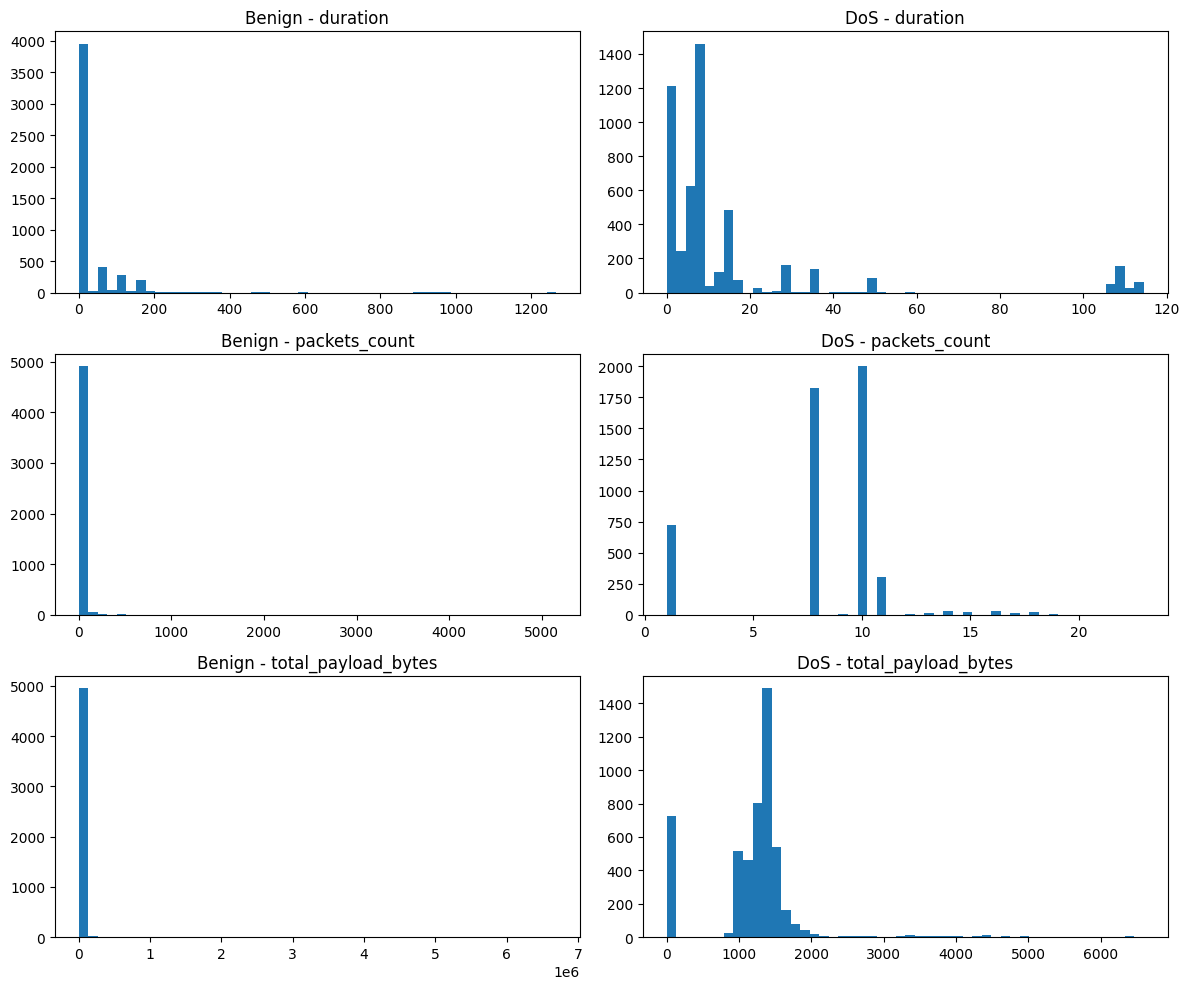

In [18]:

import matplotlib.pyplot as plt

features_to_compare = [
    "duration",
    "packets_count",
    "total_payload_bytes"
]

fig, axes = plt.subplots(len(features_to_compare), 2, figsize=(12, 10))

for i, feature in enumerate(features_to_compare):
    axes[i, 0].hist(sample_df[feature], bins=50)
    axes[i, 0].set_title(f"Benign - {feature}")
    
    axes[i, 1].hist(dos_sample_df[feature], bins=50)
    axes[i, 1].set_title(f"DoS - {feature}")

plt.tight_layout()
plt.show()


Cell-16 : Inspect friday_16_02_2018_benign_part1

In [20]:
# Cell 17: Dimensions of benign_part1

import zipfile

benign_zip_part1 = os.path.join(
    RAW_DIR, "Benign", "friday_16_02_2018_benign_part1.zip"
)

with zipfile.ZipFile(benign_zip_part1, "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        benign_part1_df = pd.read_csv(f, nrows=5000, low_memory=False)

print("Benign part1 sample shape:", benign_part1_df.shape)


Benign part1 sample shape: (5000, 323)


Cell-17: Inspect friday_16_02_2018_benign_part2

In [ ]:
benign_zip_part2 = os.path.join(
    RAW_DIR, "Benign", "friday_16_02_2018_benign_part2.zip"
)

with zipfile.ZipFile(benign_zip_part2, "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        benign_part2_df = pd.read_csv(f, nrows=5000, low_memory=False)

print("Benign part2 sample shape:", benign_part2_df.shape)


Benign part2 sample shape: (5000, 323)


Cell-19: Inspect friday_16_02_2018_benign_part3

In [22]:
# Cell 19: Dimensions of benign_part3

benign_zip_part3 = os.path.join(
    RAW_DIR, "Benign", "friday_16_02_2018_benign_part3.zip"
)

with zipfile.ZipFile(benign_zip_part3, "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        benign_part3_df = pd.read_csv(f, nrows=5000, low_memory=False)

print("Benign part3 sample shape:", benign_part3_df.shape)


Benign part3 sample shape: (2421, 323)


Cell-20: Count TOTAL rows in ALL Benign ZIP files (no merging yet)

In [23]:
# Cell 20: Count total rows in all Benign ZIP files (read-only)

import zipfile

benign_dir = os.path.join(RAW_DIR, "Benign")

benign_zip_files = []
for root, _, files in os.walk(benign_dir):
    for f in files:
        if f.endswith(".zip"):
            benign_zip_files.append(os.path.join(root, f))

print("Benign ZIP files found:")
for z in benign_zip_files:
    print("-", os.path.basename(z))

total_benign_rows = 0

for zip_path in benign_zip_files:
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            rows = sum(1 for _ in f) - 1  # subtract header
            total_benign_rows += rows
            print(f"{os.path.basename(zip_path)} → {rows} rows")

print("\nTOTAL Benign rows (all files combined):", total_benign_rows)


Benign ZIP files found:
- friday_02_03_2018_benign.zip
- friday_16_02_2018_benign_part1.zip
- friday_16_02_2018_benign_part2.zip
- friday_16_02_2018_benign_part3.zip
friday_02_03_2018_benign.zip → 4849330 rows
friday_16_02_2018_benign_part1.zip → 3295650 rows
friday_16_02_2018_benign_part2.zip → 544081 rows
friday_16_02_2018_benign_part3.zip → 2421 rows

TOTAL Benign rows (all files combined): 8691482


Cell-21: Count TOTAL rows in ALL DoS ZIP files (read-only)

In [24]:
# Cell 21: Count total rows in all DoS ZIP files (read-only)

dos_dir = os.path.join(RAW_DIR, "DoS")

dos_zip_files = []
for root, _, files in os.walk(dos_dir):
    for f in files:
        if f.endswith(".zip"):
            dos_zip_files.append(os.path.join(root, f))

print("DoS ZIP files found:")
for z in dos_zip_files:
    print("-", os.path.basename(z))

total_dos_rows = 0

for zip_path in dos_zip_files:
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            rows = sum(1 for _ in f) - 1  # subtract header
            total_dos_rows += rows
            print(f"{os.path.basename(zip_path)} → {rows} rows")

print("\nTOTAL DoS rows (all files combined):", total_dos_rows)


DoS ZIP files found:
- thursday_15_02_2018_DoS_Golden_Eye.zip
- thursday_15_02_2018_DoS_Slowloris.zip
thursday_15_02_2018_DoS_Golden_Eye.zip → 29485 rows
thursday_15_02_2018_DoS_Slowloris.zip → 8269 rows

TOTAL DoS rows (all files combined): 37754


Cell-22: Inspect Botnet dataset dimensions

In [25]:

botnet_dir = os.path.join(RAW_DIR, "Botnet")

botnet_zip_files = []
for root, _, files in os.walk(botnet_dir):
    for f in files:
        if f.endswith(".zip"):
            botnet_zip_files.append(os.path.join(root, f))

print("Botnet ZIP files:", botnet_zip_files)

with zipfile.ZipFile(botnet_zip_files[0], "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        botnet_sample_df = pd.read_csv(f, nrows=5000, low_memory=False)

print("Botnet sample shape:", botnet_sample_df.shape)


Botnet ZIP files: ['c:\\HTML\\FL_IDS_Vehicle\\data_raw\\Vehicle DS\\Botnet\\friday_02_03_2018_bot.zip']
Botnet sample shape: (5000, 323)


Cell-23: Inspect Brute_Force ZIP — Part 1 (dimensions only)

In [26]:

bruteforce_dir = os.path.join(RAW_DIR, "Brute_Force")

bruteforce_zip_files = []
for root, _, files in os.walk(bruteforce_dir):
    for f in files:
        if f.endswith(".zip"):
            bruteforce_zip_files.append(os.path.join(root, f))

print("Brute_Force ZIP files:")
for z in bruteforce_zip_files:
    print("-", os.path.basename(z))

# Inspect first Brute_Force ZIP
bf_zip_1 = bruteforce_zip_files[0]

with zipfile.ZipFile(bf_zip_1, "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        bf_sample_df_1 = pd.read_csv(f, nrows=5000, low_memory=False)

print("\nBrute_Force part 1 sample shape:", bf_sample_df_1.shape)


Brute_Force ZIP files:
- friday_23_02_2018_BF_web.zip
- friday_23_02_2018_BF_XSS.zip

Brute_Force part 1 sample shape: (246, 323)


Cell-24: Inspect Brute_Force ZIP — Part 2 (dimensions only)

In [27]:

# Inspect second Brute_Force ZIP
bf_zip_2 = bruteforce_zip_files[1]

with zipfile.ZipFile(bf_zip_2, "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        bf_sample_df_2 = pd.read_csv(f, nrows=5000, low_memory=False)

print("Brute_Force part 2 sample shape:", bf_sample_df_2.shape)


Brute_Force part 2 sample shape: (148, 323)


Cell-25 : Count TOTAL rows in ALL Brute_Force ZIP files (read-only)

In [28]:

bruteforce_dir = os.path.join(RAW_DIR, "Brute_Force")

bruteforce_zip_files = []
for root, _, files in os.walk(bruteforce_dir):
    for f in files:
        if f.endswith(".zip"):
            bruteforce_zip_files.append(os.path.join(root, f))

print("Brute_Force ZIP files found:")
for z in bruteforce_zip_files:
    print("-", os.path.basename(z))

total_bruteforce_rows = 0

for zip_path in bruteforce_zip_files:
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            rows = sum(1 for _ in f) - 1  # subtract header
            total_bruteforce_rows += rows
            print(f"{os.path.basename(zip_path)} → {rows} rows")

print("\nTOTAL Brute_Force rows (all files combined):", total_bruteforce_rows)


Brute_Force ZIP files found:
- friday_23_02_2018_BF_web.zip
- friday_23_02_2018_BF_XSS.zip
friday_23_02_2018_BF_web.zip → 246 rows
friday_23_02_2018_BF_XSS.zip → 148 rows

TOTAL Brute_Force rows (all files combined): 394


Cell-26: Inspect DDoS_or_LOIC dataset (dimensions only)

In [29]:
ddos_dir = os.path.join(RAW_DIR, "DDoS_or_LOIC")

ddos_zip_files = []
for root, _, files in os.walk(ddos_dir):
    for f in files:
        if f.endswith(".zip"):
            ddos_zip_files.append(os.path.join(root, f))

print("DDoS_or_LOIC ZIP files:", ddos_zip_files)

with zipfile.ZipFile(ddos_zip_files[0], "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        ddos_sample_df = pd.read_csv(f, nrows=5000, low_memory=False)

print("DDoS_or_LOIC sample shape:", ddos_sample_df.shape)


DDoS_or_LOIC ZIP files: ['c:\\HTML\\FL_IDS_Vehicle\\data_raw\\Vehicle DS\\DDoS_or_LOIC\\tuesday_20_02_2018_loic_http.zip']
DDoS_or_LOIC sample shape: (5000, 323)


Cell-27: Inspect SQL_Injection dataset (dimensions only)

In [30]:
sql_dir = os.path.join(RAW_DIR, "SQL_Injection")

sql_zip_files = []
for root, _, files in os.walk(sql_dir):
    for f in files:
        if f.endswith(".zip"):
            sql_zip_files.append(os.path.join(root, f))

print("SQL_Injection ZIP files:", sql_zip_files)

with zipfile.ZipFile(sql_zip_files[0], "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        sql_sample_df = pd.read_csv(f, nrows=5000, low_memory=False)

print("SQL_Injection sample shape:", sql_sample_df.shape)


SQL_Injection ZIP files: ['c:\\HTML\\FL_IDS_Vehicle\\data_raw\\Vehicle DS\\SQL_Injection\\friday_23_02_2018_SQL_Injection.zip']
SQL_Injection sample shape: (66, 323)


Cell-28: Create benign_combined.csv (NEW file, read-only raw)

In [31]:
import zipfile

OUTPUT_DIR = os.path.join(BASE_DIR, "data_processed")
os.makedirs(OUTPUT_DIR, exist_ok=True)

benign_output_path = os.path.join(OUTPUT_DIR, "benign_combined.csv")

benign_dir = os.path.join(RAW_DIR, "Benign")

benign_zip_files = []
for root, _, files in os.walk(benign_dir):
    for f in files:
        if f.endswith(".zip"):
            benign_zip_files.append(os.path.join(root, f))

print("Combining Benign ZIP files:")
for z in benign_zip_files:
    print("-", os.path.basename(z))

first_chunk = True
total_rows_written = 0

for zip_path in benign_zip_files:
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            for chunk in pd.read_csv(f, chunksize=200_000, low_memory=False):
                chunk.to_csv(
                    benign_output_path,
                    mode="w" if first_chunk else "a",
                    index=False,
                    header=first_chunk
                )
                rows = len(chunk)
                total_rows_written += rows
                first_chunk = False

print("\nbenign_combined.csv created successfully")
print("Total rows written:", total_rows_written)
print("Saved at:", benign_output_path)


Combining Benign ZIP files:
- friday_02_03_2018_benign.zip
- friday_16_02_2018_benign_part1.zip
- friday_16_02_2018_benign_part2.zip
- friday_16_02_2018_benign_part3.zip

benign_combined.csv created successfully
Total rows written: 8691482
Saved at: c:\HTML\FL_IDS_Vehicle\data_processed\benign_combined.csv


Cell-28: Create dos_combined.csv (NEW file, raw untouched)

In [32]:
import zipfile

dos_output_path = os.path.join(OUTPUT_DIR, "dos_combined.csv")

dos_dir = os.path.join(RAW_DIR, "DoS")

dos_zip_files = []
for root, _, files in os.walk(dos_dir):
    for f in files:
        if f.endswith(".zip"):
            dos_zip_files.append(os.path.join(root, f))

print("Combining DoS ZIP files:")
for z in dos_zip_files:
    print("-", os.path.basename(z))

first_chunk = True
total_rows_written = 0

for zip_path in dos_zip_files:
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            for chunk in pd.read_csv(f, chunksize=100_000, low_memory=False):
                chunk.to_csv(
                    dos_output_path,
                    mode="w" if first_chunk else "a",
                    index=False,
                    header=first_chunk
                )
                rows = len(chunk)
                total_rows_written += rows
                first_chunk = False

print("\ndos_combined.csv created successfully")
print("Total rows written:", total_rows_written)
print("Saved at:", dos_output_path)


Combining DoS ZIP files:
- thursday_15_02_2018_DoS_Golden_Eye.zip
- thursday_15_02_2018_DoS_Slowloris.zip

dos_combined.csv created successfully
Total rows written: 37754
Saved at: c:\HTML\FL_IDS_Vehicle\data_processed\dos_combined.csv


Cell-29: Create bruteforce_combined.csv

In [33]:
bf_output_path = os.path.join(OUTPUT_DIR, "bruteforce_combined.csv")

bf_dir = os.path.join(RAW_DIR, "Brute_Force")

bf_zip_files = []
for root, _, files in os.walk(bf_dir):
    for f in files:
        if f.endswith(".zip"):
            bf_zip_files.append(os.path.join(root, f))

print("Combining Brute_Force ZIP files:")
for z in bf_zip_files:
    print("-", os.path.basename(z))

first_chunk = True
total_rows_written = 0

for zip_path in bf_zip_files:
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            for chunk in pd.read_csv(f, chunksize=10_000, low_memory=False):
                chunk.to_csv(
                    bf_output_path,
                    mode="w" if first_chunk else "a",
                    index=False,
                    header=first_chunk
                )
                rows = len(chunk)
                total_rows_written += rows
                first_chunk = False

print("\nbruteforce_combined.csv created successfully")
print("Total rows written:", total_rows_written)
print("Saved at:", bf_output_path)


Combining Brute_Force ZIP files:
- friday_23_02_2018_BF_web.zip
- friday_23_02_2018_BF_XSS.zip

bruteforce_combined.csv created successfully
Total rows written: 394
Saved at: c:\HTML\FL_IDS_Vehicle\data_processed\bruteforce_combined.csv


Cell-30: Create botnet_combined.csv

In [34]:

botnet_output_path = os.path.join(OUTPUT_DIR, "botnet_combined.csv")

botnet_dir = os.path.join(RAW_DIR, "Botnet")

botnet_zip_files = []
for root, _, files in os.walk(botnet_dir):
    for f in files:
        if f.endswith(".zip"):
            botnet_zip_files.append(os.path.join(root, f))

print("Botnet ZIP file:")
print("-", os.path.basename(botnet_zip_files[0]))

first_chunk = True
total_rows_written = 0

with zipfile.ZipFile(botnet_zip_files[0], "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        for chunk in pd.read_csv(f, chunksize=100_000, low_memory=False):
            chunk.to_csv(
                botnet_output_path,
                mode="w" if first_chunk else "a",
                index=False,
                header=first_chunk
            )
            rows = len(chunk)
            total_rows_written += rows
            first_chunk = False

print("\nbotnet_combined.csv created successfully")
print("Total rows written:", total_rows_written)
print("Saved at:", botnet_output_path)


Botnet ZIP file:
- friday_02_03_2018_bot.zip

botnet_combined.csv created successfully
Total rows written: 286099
Saved at: c:\HTML\FL_IDS_Vehicle\data_processed\botnet_combined.csv


Cell-31: Create ddos_combined.csv (DDoS_or_LOIC)

In [35]:
ddos_output_path = os.path.join(OUTPUT_DIR, "ddos_combined.csv")

ddos_dir = os.path.join(RAW_DIR, "DDoS_or_LOIC")

ddos_zip_files = []
for root, _, files in os.walk(ddos_dir):
    for f in files:
        if f.endswith(".zip"):
            ddos_zip_files.append(os.path.join(root, f))

print("DDoS_or_LOIC ZIP file:")
print("-", os.path.basename(ddos_zip_files[0]))

first_chunk = True
total_rows_written = 0

with zipfile.ZipFile(ddos_zip_files[0], "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        for chunk in pd.read_csv(f, chunksize=100_000, low_memory=False):
            chunk.to_csv(
                ddos_output_path,
                mode="w" if first_chunk else "a",
                index=False,
                header=first_chunk
            )
            rows = len(chunk)
            total_rows_written += rows
            first_chunk = False

print("\nddos_combined.csv created successfully")
print("Total rows written:", total_rows_written)
print("Saved at:", ddos_output_path)


DDoS_or_LOIC ZIP file:
- tuesday_20_02_2018_loic_http.zip

ddos_combined.csv created successfully
Total rows written: 289527
Saved at: c:\HTML\FL_IDS_Vehicle\data_processed\ddos_combined.csv


Cell-32: Create sqli_combined.csv (SQL_Injection)

In [36]:
sqli_output_path = os.path.join(OUTPUT_DIR, "sqli_combined.csv")

sqli_dir = os.path.join(RAW_DIR, "SQL_Injection")

sqli_zip_files = []
for root, _, files in os.walk(sqli_dir):
    for f in files:
        if f.endswith(".zip"):
            sqli_zip_files.append(os.path.join(root, f))

print("SQL_Injection ZIP file:")
print("-", os.path.basename(sqli_zip_files[0]))

first_chunk = True
total_rows_written = 0

with zipfile.ZipFile(sqli_zip_files[0], "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        for chunk in pd.read_csv(f, chunksize=10_000, low_memory=False):
            chunk.to_csv(
                sqli_output_path,
                mode="w" if first_chunk else "a",
                index=False,
                header=first_chunk
            )
            rows = len(chunk)
            total_rows_written += rows
            first_chunk = False

print("\nsqli_combined.csv created successfully")
print("Total rows written:", total_rows_written)
print("Saved at:", sqli_output_path)


SQL_Injection ZIP file:
- friday_23_02_2018_SQL_Injection.zip

sqli_combined.csv created successfully
Total rows written: 66
Saved at: c:\HTML\FL_IDS_Vehicle\data_processed\sqli_combined.csv


Next logical steps (in order):

Create attack_combined.csv
(DoS + DDoS + Botnet)

Downsample benign_combined.csv

Merge → phase1_dataset.csv

Drop non-numeric columns

Label mapping (0 = Benign, 1 = Attack)

Scaling

Client-wise split (5 vehicles)

Federated LR training

Cell-33: Create attack_combined.csv (DoS + DDoS + Botnet)

In [5]:
# Cell 33 (final, path-correct): Create attack_combined.csv

import os
import pandas as pd

# Fix base directory when running from notebook/
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
OUTPUT_DIR = os.path.join(BASE_DIR, "data_processed")

attack_output_path = os.path.join(OUTPUT_DIR, "attack_combined.csv")

attack_files = [
    os.path.join(OUTPUT_DIR, "dos_combined.csv"),
    os.path.join(OUTPUT_DIR, "ddos_combined.csv"),
    os.path.join(OUTPUT_DIR, "botnet_combined.csv")
]

print("Combining attack datasets:")
for f in attack_files:
    print("-", os.path.basename(f), "exists:", os.path.exists(f))

first_chunk = True
total_rows_written = 0

for file_path in attack_files:
    for chunk in pd.read_csv(file_path, chunksize=200_000, low_memory=False):
        chunk.to_csv(
            attack_output_path,
            mode="w" if first_chunk else "a",
            index=False,
            header=first_chunk
        )
        rows = len(chunk)
        total_rows_written += rows
        first_chunk = False

print("\nattack_combined.csv created successfully")
print("Total attack rows written:", total_rows_written)
print("Saved at:", attack_output_path)


Combining attack datasets:
- dos_combined.csv exists: True
- ddos_combined.csv exists: True
- botnet_combined.csv exists: True

attack_combined.csv created successfully
Total attack rows written: 613380
Saved at: c:\HTML\FL_IDS_Vehicle\data_processed\attack_combined.csv


Cell-34: Downsample Benign to 3:1 ratio

In [6]:

import os
import pandas as pd
import numpy as np

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
OUTPUT_DIR = os.path.join(BASE_DIR, "data_processed")

benign_path = os.path.join(OUTPUT_DIR, "benign_combined.csv")
attack_path = os.path.join(OUTPUT_DIR, "attack_combined.csv")
benign_sampled_path = os.path.join(OUTPUT_DIR, "benign_sampled.csv")

# Desired ratio
attack_rows = 613380
target_benign_rows = attack_rows * 3

print("Target benign rows:", target_benign_rows)

chunk_size = 200_000
rows_written = 0

rng = np.random.default_rng(seed=42)

with open(benign_sampled_path, "w") as out_f:
    first_chunk = True
    
    for chunk in pd.read_csv(benign_path, chunksize=chunk_size, low_memory=False):
        if rows_written >= target_benign_rows:
            break
        
        remaining = target_benign_rows - rows_written
        take_n = min(len(chunk), remaining)
        
        sampled_chunk = chunk.sample(n=take_n, random_state=42)
        
        sampled_chunk.to_csv(
            out_f,
            index=False,
            header=first_chunk
        )
        
        rows_written += take_n
        first_chunk = False
        
        print(f"Written benign rows so far: {rows_written}")

print("\nbenign_sampled.csv created successfully")
print("Total benign rows written:", rows_written)
print("Saved at:", benign_sampled_path)


Target benign rows: 1840140
Written benign rows so far: 200000
Written benign rows so far: 400000
Written benign rows so far: 600000
Written benign rows so far: 800000
Written benign rows so far: 1000000
Written benign rows so far: 1200000
Written benign rows so far: 1400000
Written benign rows so far: 1600000
Written benign rows so far: 1800000
Written benign rows so far: 1840140

benign_sampled.csv created successfully
Total benign rows written: 1840140
Saved at: c:\HTML\FL_IDS_Vehicle\data_processed\benign_sampled.csv


Cell-35: Create phase1_dataset.csv (FINAL Phase-1 dataset)

In [7]:

import os
import pandas as pd

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
OUTPUT_DIR = os.path.join(BASE_DIR, "data_processed")

benign_sampled_path = os.path.join(OUTPUT_DIR, "benign_sampled.csv")
attack_path = os.path.join(OUTPUT_DIR, "attack_combined.csv")
phase1_output_path = os.path.join(OUTPUT_DIR, "phase1_dataset.csv")

print("Merging datasets:")
print("- benign_sampled.csv")
print("- attack_combined.csv")

first_chunk = True
total_rows_written = 0

for file_path in [benign_sampled_path, attack_path]:
    for chunk in pd.read_csv(file_path, chunksize=200_000, low_memory=False):
        chunk.to_csv(
            phase1_output_path,
            mode="w" if first_chunk else "a",
            index=False,
            header=first_chunk
        )
        rows = len(chunk)
        total_rows_written += rows
        first_chunk = False

print("\nphase1_dataset.csv created successfully")
print("Total rows written:", total_rows_written)
print("Saved at:", phase1_output_path)


Merging datasets:
- benign_sampled.csv
- attack_combined.csv

phase1_dataset.csv created successfully
Total rows written: 2453520
Saved at: c:\HTML\FL_IDS_Vehicle\data_processed\phase1_dataset.csv


PROJECT: Final Year Project – FL-based IDS for Vehicle IoT

Dataset:
- CIC-IDS2018 (subset)
- Raw data untouched in data_raw/
- Class-wise combined datasets created:
  benign_combined.csv (8.69M rows)
  dos_combined.csv (37,754 rows)
  ddos_combined.csv (289,527 rows)
  botnet_combined.csv (286,099 rows)
  bruteforce_combined.csv (394 rows)
  sqli_combined.csv (66 rows)

Phase-1 Dataset:
- Option 1 chosen: Benign vs DoS + DDoS + Botnet
- attack_combined.csv: 613,380 rows
- benign_sampled.csv: 1,840,140 rows (3:1 ratio)
- phase1_dataset.csv: 2,453,520 rows
- Schema: 323 features

Structure:
- Dataset_creation.ipynb → dataset construction (done)
- preprocess.ipynb → preprocessing & ML (starting now)

Next step:
- Drop non-numeric columns
- Binary label mapping
- Scaling
- Client split (5 vehicles)
- Logistic Regression + Federated Learning